# 文件: chart_51_1.py

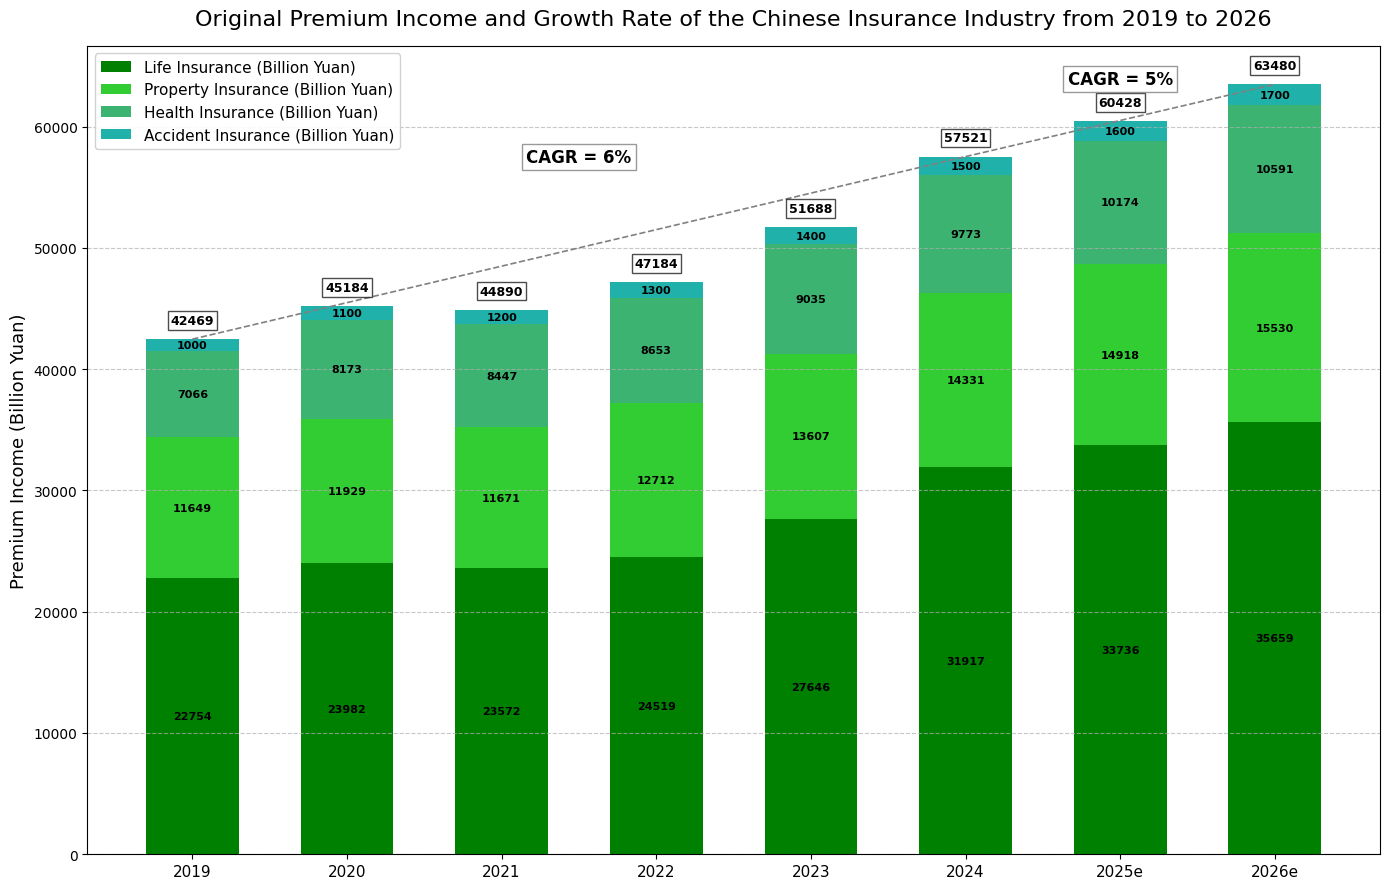

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = ["2019", "2020", "2021", "2022", "2023", "2024", "2025e", "2026e"]
# Premium income of each insurance type (in billions of yuan), the data is roughly simulated and can be adjusted according to actual situations
premium_data = np.array([
    [22754, 11649, 7066, 1000],    # 2019
    [23982, 11929, 8173, 1100],    # 2020
    [23572, 11671, 8447, 1200],    # 2021
    [24519, 12712, 8653, 1300],    # 2022
    [27646, 13607, 9035, 1400],    # 2023
    [31917, 14331, 9773, 1500],    # 2024
    [33736, 14918, 10174, 1600],   # 2025e
    [35659, 15530, 10591, 1700]    # 2026e
])

# Colors corresponding to each insurance type
colors = ['green', 'limegreen', 'mediumseagreen', 'lightseagreen']
# Insurance type names
insurance_types = ["Life Insurance (Billion Yuan)", "Property Insurance (Billion Yuan)", "Health Insurance (Billion Yuan)", "Accident Insurance (Billion Yuan)"]

x = np.arange(len(years))  # x-axis tick positions
bar_width = 0.6  # Bar width

fig, ax = plt.subplots(figsize=(14, 9))  # Further increase the chart size

# Draw a stacked bar chart
bottom = np.zeros(len(years))
for i in range(premium_data.shape[1]):
    bars = ax.bar(x, premium_data[:, i], width=bar_width, bottom=bottom, color=colors[i], label=insurance_types[i])
    bottom += premium_data[:, i]
    
    # Add data labels above each bar
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 500:  # Only show labels with sufficient height to avoid overcrowding
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                bar.get_y() + height/2,
                f'{int(height)}',
                ha='center', va='center',
                color='black', fontsize=8, fontweight='bold'
            )

# Add a title
ax.set_title('Original Premium Income and Growth Rate of the Chinese Insurance Industry from 2019 to 2026', fontsize=16, pad=15)

# Set x-axis tick labels
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)

# Add a y-axis label
ax.set_ylabel('Premium Income (Billion Yuan)', fontsize=13)

# Add a legend
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=11)

# Calculate the total premium for each year
total_premiums = premium_data.sum(axis=1)

# Add total premium annotations
for i, total in enumerate(total_premiums):
    ax.text(x[i], total + 1000,  # Adjust the vertical position to avoid overlapping with the bars
            f'{int(total)}', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, pad=2.0))

# CAGR annotation function
def add_cagr_annotation(start_idx, end_idx, cagr_value, ax, x, total_premiums):
    """Add CAGR polyline annotation"""
    start_x = x[start_idx]
    end_x = x[end_idx]
    start_y = total_premiums[start_idx]
    end_y = total_premiums[end_idx]
    
    # Calculate the position of the midpoint
    mid_x = (start_x + end_x) / 2
    mid_y1 = start_y + (end_y - start_y) * 0.3
    mid_y2 = start_y + (end_y - start_y) * 0.7
    
    # Draw a polyline
    ax.plot([start_x, end_x], [start_y, end_y], 
            'gray', linestyle='--', linewidth=1.2)
    
    # Add CAGR text
    text_x = mid_x
    text_y = mid_y2 + (end_y - start_y) * 0.25
    ax.text(text_x, text_y, f'CAGR = {cagr_value}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=3.0))

# Add CAGR annotation from 2019 to 2024
add_cagr_annotation(0, 5, 6, ax, x, total_premiums)

# Add CAGR annotation from 2024 to 2026
add_cagr_annotation(5, 7, 5, ax, x, total_premiums)

# Beautify the chart
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.tight_layout()  # Automatically adjust the layout

plt.show()

# 文件: chart_51_2.py

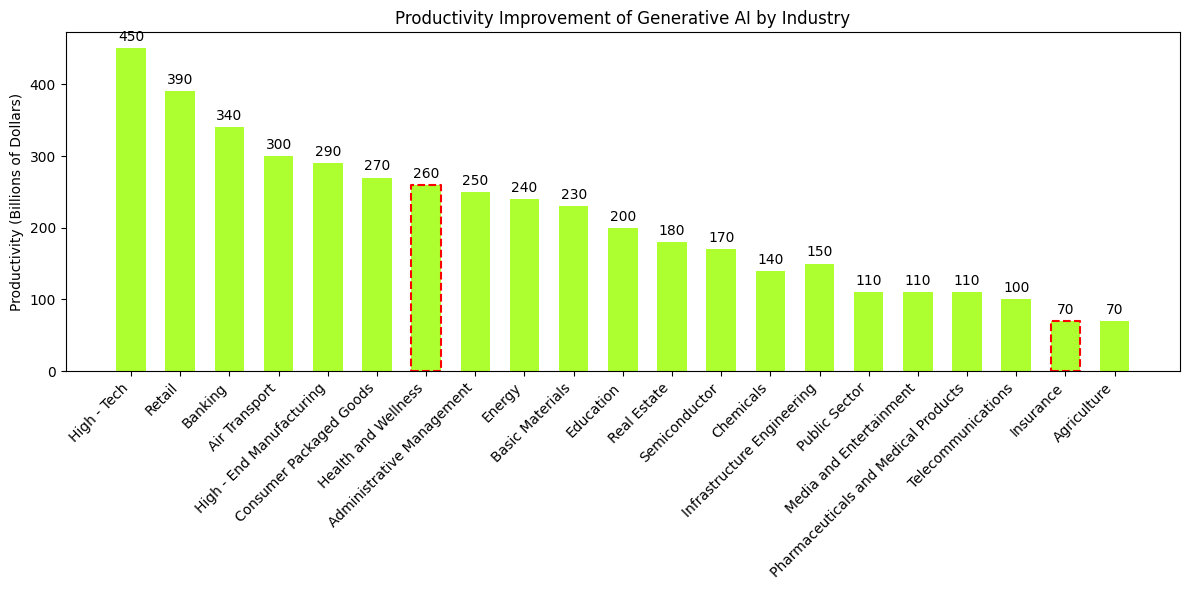

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Industry names
industries = ["High - Tech", "Retail", "Banking", "Air Transport", "High - End Manufacturing", "Consumer Packaged Goods",
              "Health and Wellness", "Administrative Management", "Energy", "Basic Materials", "Education", "Real Estate",
              "Semiconductor", "Chemicals", "Infrastructure Engineering", "Public Sector", "Media and Entertainment",
              "Pharmaceuticals and Medical Products", "Telecommunications", "Insurance", "Agriculture"]
# Productivity data (in billions of dollars), roughly simulated and can be adjusted according to actual situation
productivity = [450, 390, 340, 300, 290, 270, 260, 250, 240, 230, 200, 180, 170, 140, 150, 110, 110, 110, 100, 70, 70]
# Mark the indices of industries that need to be specially framed
special_indices = [6, 19]  # Indices corresponding to Health and Wellness, Insurance

x = np.arange(len(industries))  # x - axis tick positions
bar_width = 0.6  # Bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Draw a bar chart, set the color to a similar green
bars = ax.bar(x, productivity, width=bar_width, color='greenyellow')

# Add a title
ax.set_title('Productivity Improvement of Generative AI by Industry')

# Set x - axis tick labels, rotate by a certain angle to avoid overlap
ax.set_xticks(x)
ax.set_xticklabels(industries, rotation=45, ha='right')

# Add red dashed boxes for special industries
for idx in special_indices:
    rect = bars[idx].get_bbox()
    ax.plot([rect.x0, rect.x1, rect.x1, rect.x0, rect.x0],
            [rect.y0, rect.y0, rect.y1, rect.y1, rect.y0],
            'r--', linewidth=1.5)

# Add numerical labels to each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # Vertical offset of 3 points
                textcoords="offset points",
                ha='center', va='bottom')

# Set y - axis label
ax.set_ylabel('Productivity (Billions of Dollars)')

plt.tight_layout()  # Automatically adjust the layout to avoid label overlap
plt.show()

# 文件: chart_51_3.py

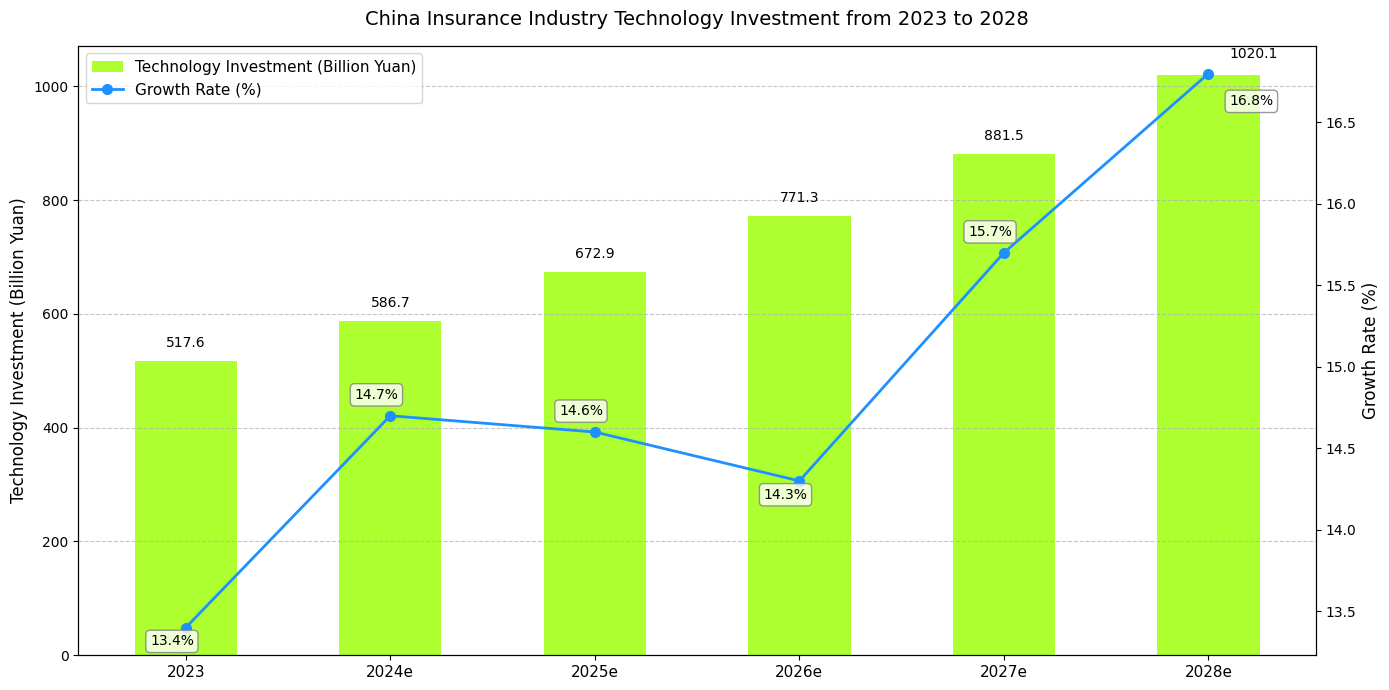

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = ["2023", "2024e", "2025e", "2026e", "2027e", "2028e"]
# Technology investment (in billions of yuan), roughly simulated and can be adjusted according to actual situation
tech_investment = [517.6, 586.7, 672.9, 771.3, 881.5, 1020.1]
# Growth rate (%), roughly simulated and can be adjusted according to actual situation
growth_rate = [13.4, 14.7, 14.6, 14.3, 15.7, 16.8]

x = np.arange(len(years))  # x-axis tick positions
bar_width = 0.5  # Bar width

fig, ax1 = plt.subplots(figsize=(14, 7))  # Further increase the chart width

# Draw the technology investment bar chart
bars = ax1.bar(x, tech_investment, width=bar_width, label='Technology Investment (Billion Yuan)', color='greenyellow')
ax1.set_ylabel('Technology Investment (Billion Yuan)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=11)

# Add numerical labels to the bar chart
for i, bar in enumerate(bars):
    height = bar.get_height()
    # Special handling for the last label position
    if i == len(bars) - 1:
        ax1.annotate(f'{tech_investment[i]}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(15, 10),  # Offset to the upper right
                    textcoords="offset points",
                    ha='left', va='bottom',  # Left-aligned, bottom-aligned
                    fontsize=10)
    else:
        ax1.annotate(f'{tech_investment[i]}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

# Create a second y-axis and draw the growth rate line chart
ax2 = ax1.twinx()
line, = ax2.plot(x, growth_rate, marker='o', markersize=7, label='Growth Rate (%)', 
                color='dodgerblue', linewidth=2)
ax2.set_ylabel('Growth Rate (%)', fontsize=12)

# Add numerical labels to the line chart
for i, rate in enumerate(growth_rate):
    # Special handling for the last label position
    if i == len(growth_rate) - 1:
        ax2.annotate(f'{rate}%',
                    xy=(x[i], rate),
                    xytext=(15, -15),  # Offset to the lower right
                    textcoords="offset points",
                    ha='left', va='top',  # Left-aligned, top-aligned
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    else:
        ax2.annotate(f'{rate}%',
                    xy=(x[i], rate),
                    xytext=(-10, 10) if rate > 14.5 else (-10, -15),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Add a title
ax1.set_title('China Insurance Industry Technology Investment from 2023 to 2028', fontsize=14, pad=15)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

# Beautify the chart
ax1.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.tight_layout()  # Automatically adjust the layout

plt.show()

# 文件: chart_51_4.py

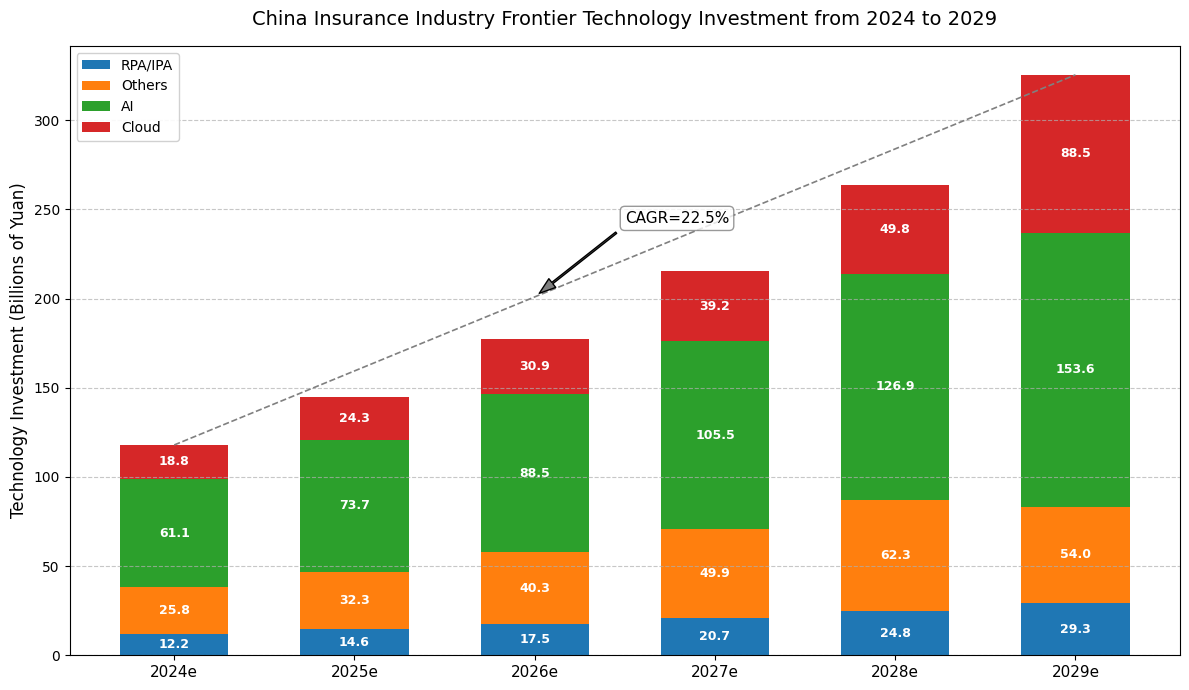

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = ["2024e", "2025e", "2026e", "2027e", "2028e", "2029e"]

# Investment data for each technology (in billions of yuan), in the order of RPA/IPA, Others, AI, Cloud, Big Data
# Note: The last value is calculated by subtracting the previous values from the total to ensure the sum of each layer is correct
tech_investment = np.array([
    [12.2, 25.8, 61.1, 117.9 - (12.2 + 25.8 + 61.1)],  # Total in 2024e: 12.2+25.8+61.1+18.8=117.9
    [14.6, 32.3, 73.7, 144.9 - (14.6 + 32.3 + 73.7)],  # Total in 2025e: 14.6+32.3+73.7+24.3=144.9
    [17.5, 40.3, 88.5, 177.2 - (17.5 + 40.3 + 88.5)],  # Total in 2026e: 17.5+40.3+88.5+30.9=177.2
    [20.7, 49.9, 105.5, 215.3 - (20.7 + 49.9 + 105.5)],# Total in 2027e: 20.7+49.9+105.5+39.2=215.3
    [24.8, 62.3, 126.9, 263.8 - (24.8 + 62.3 + 126.9)],# Total in 2028e: 24.8+62.3+126.9+50.0=263.8
    [29.3, 54.0, 153.6, 325.4 - (29.3 + 54.0 + 153.6)] # Total in 2029e: 29.3+54.0+153.6+88.5=325.4
])

# Colors corresponding to each technology (as close as possible to the original image)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Technology names (with units)
tech_names = ["RPA/IPA", "Others", "AI", "Cloud", "Big Data"]

x = np.arange(len(years))  # x-axis tick positions
bar_width = 0.6  # Width of the bar chart

fig, ax = plt.subplots(figsize=(12, 7))

# Draw the stacked bar chart
bottom = np.zeros(len(years))
for i in range(tech_investment.shape[1]):
    bars = ax.bar(x, tech_investment[:, i], width=bar_width, bottom=bottom, 
                  color=colors[i], label=tech_names[i])
    bottom += tech_investment[:, i]
    
    # Label the values in each stacked layer
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # Only label non-zero values
            ax.text(
                bar.get_x() + bar.get_width()/2, 
                bar.get_y() + height/2,
                f'{height:.1f}',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )

# Add the title
ax.set_title('China Insurance Industry Frontier Technology Investment from 2024 to 2029', fontsize=14, pad=15)

# Set x-axis tick labels
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)

# Add y-axis label
ax.set_ylabel('Technology Investment (Billions of Yuan)', fontsize=12)

# Add the legend (placed on the right side of the chart)
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=10)

# Calculate and label the CAGR (22.5%)
cagr = 22.5
start_value = tech_investment[0].sum()
end_value = tech_investment[-1].sum()

# Draw the CAGR line
ax.plot([x[0], x[-1]], [start_value, end_value], 'gray', linestyle='--', linewidth=1.2)

# Add the CAGR text label
ax.annotate(
    f'CAGR={cagr}%', 
    xy=(x[2], start_value + (end_value - start_value)*0.4), 
    xytext=(x[2]+0.5, start_value + (end_value - start_value)*0.6),
    arrowprops=dict(facecolor='gray', shrink=0.05, width=1.2, headwidth=8),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# Beautify the chart
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.tight_layout()  # Automatically adjust the layout

plt.show()

# 文件: chart_51_5.py

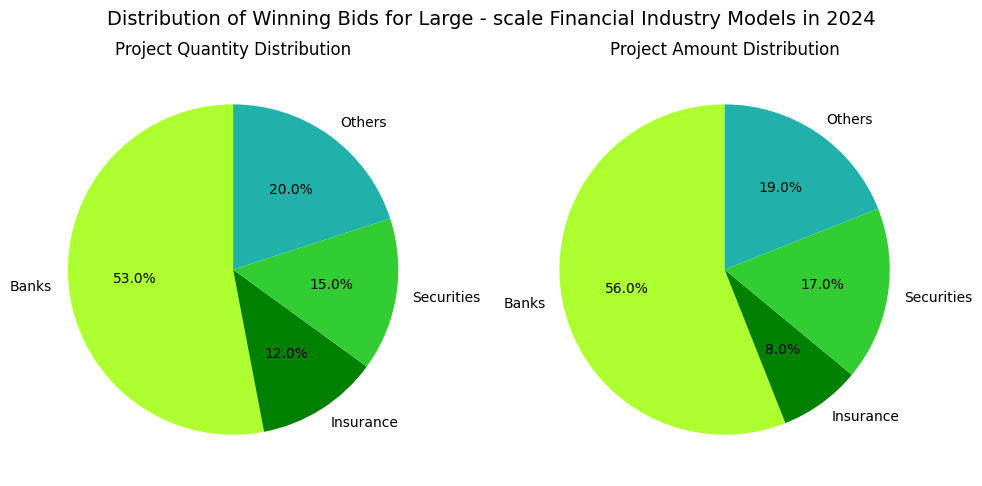

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data definition, project quantity distribution and project amount distribution
labels = ["Banks", "Insurance", "Securities", "Others"]
sizes_quantity = [53, 12, 15, 20]  # Project quantity distribution, roughly simulated
sizes_amount = [56, 8, 17, 19]  # Project amount distribution, roughly simulated
# Color settings, as close to the original image as possible
colors = ["greenyellow", "green", "limegreen", "lightseagreen"]

# Create a canvas and sub - plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Draw a pie chart of project quantity distribution
ax1.pie(sizes_quantity, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Project Quantity Distribution')

# Draw a pie chart of project amount distribution
ax2.pie(sizes_amount, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Project Amount Distribution')

# Add a main title
fig.suptitle('Distribution of Winning Bids for Large - scale Financial Industry Models in 2024', fontsize=14)

plt.tight_layout()
plt.show()